# Step 1: Portfolio QUBO — 8 Assets, 8 Qubits (Hartford Sectors)
## YQuantum 2026 — Capgemini / The Hartford Challenge

**Sectors:** Gov Bonds, IG Credit, Cash, HY Credit (2 assets per sector)

These are the 4 sectors most relevant to The Hartford as an insurance company:
- **Gov Bonds** — regulatory requirement, lowest capital charge (0.01)
- **IG Credit** — core holding, stable yield, low capital charge (0.02)
- **Cash** — liquidity buffer for paying claims, lowest capital charge (0.005)
- **HY Credit** — yield enhancement, carefully limited (capital charge 0.07)

---

In [5]:
pip install openpyxl 

Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## 1. Load Dataset

In [8]:
xlsx_path = 'investment_dataset_full.xlsx'

assets_all = pd.read_excel(xlsx_path, sheet_name='assets')
cov_df = pd.read_excel(xlsx_path, sheet_name='covariance', index_col=0)
corr_df = pd.read_excel(xlsx_path, sheet_name='correlation', index_col=0)
scenarios = pd.read_excel(xlsx_path, sheet_name='scenarios')

assets_all['sharpe'] = assets_all['exp_return'] / assets_all['volatility']

print(f'Dataset: {assets_all.shape[0]} assets, {scenarios.shape[0]} scenarios')
print(f'Sectors: {assets_all["sector"].nunique()}')
print(assets_all['sector'].value_counts().to_string())

Dataset: 50 assets, 1200 scenarios
Sectors: 8
sector
IG Credit         12
Equities US       10
HY Credit         10
Equities Intl      7
Gov Bonds          5
Cash               3
Real Estate        2
Infrastructure     1


## 2. Select 8 Assets (2 per Hartford Sector)

In [9]:
# Hartford-relevant sectors: low capital charge, high liquidity
target_sectors = ['Gov Bonds', 'IG Credit', 'Cash', 'HY Credit']

# Pick top 2 Sharpe ratio assets from each sector
sel8 = []
for sector in target_sectors:
    subset = assets_all[assets_all['sector'] == sector].sort_values('sharpe', ascending=False)
    top2 = subset.head(2)
    for _, row in top2.iterrows():
        sel8.append(row)

sel8_df = pd.DataFrame(sel8).set_index('asset_id')
sel8_ids = sel8_df.index.tolist()
sectors = sel8_df['sector'].tolist()

mu = sel8_df['exp_return'].values
w_max = sel8_df['w_max'].values
cov8 = cov_df.loc[sel8_ids, sel8_ids].values
corr8 = corr_df.loc[sel8_ids, sel8_ids].values
n = 8

print('Selected 8 Assets (2 per Hartford sector, best Sharpe):')
sel8_df[['sector', 'rating', 'exp_return', 'volatility', 'sharpe',
         'liquidity', 'capital_charge', 'w_max']].round(4)

Selected 8 Assets (2 per Hartford sector, best Sharpe):


,sector,rating,exp_return,volatility,sharpe,liquidity,capital_charge,w_max
asset_id,,,,,,,,
A017,Gov Bonds,AA,0.0183,0.0364,0.5031,4,0.010,0.20
A042,Gov Bonds,AA,0.0181,0.0385,0.4709,5,0.010,0.20
A026,IG Credit,A,0.0334,0.0508,0.6576,4,0.020,0.12
A043,IG Credit,A,0.0369,0.0593,0.6216,3,0.020,0.12
A007,Cash,NaN,0.0164,0.0121,1.3532,4,0.005,0.25
A048,Cash,NaN,0.0136,0.0119,1.1463,5,0.005,0.25
A047,HY Credit,B,0.0730,0.1132,0.6446,3,0.070,0.06
A037,HY Credit,B,0.0743,0.1186,0.6266,3,0.070,0.06


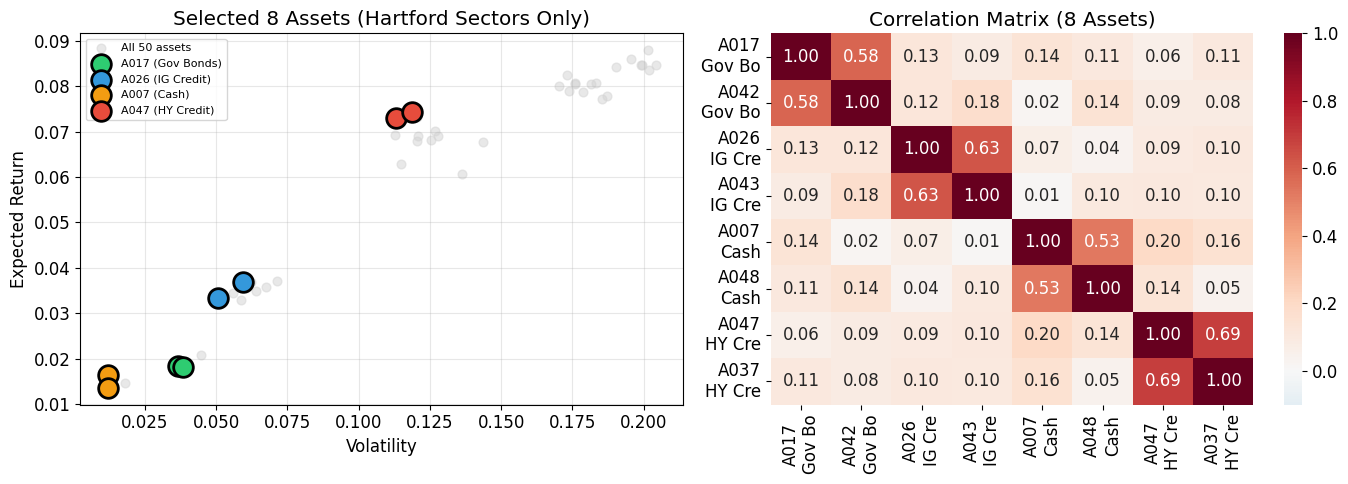


Sum of w_max = 1.26
Average capital charge = 0.026 (low — good for insurer!)
Average liquidity = 3.9 (high — good for claims!)


In [10]:
# Risk-return plot for selected assets
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All assets + selected highlighted
axes[0].scatter(assets_all['volatility'], assets_all['exp_return'],
               c='lightgray', s=40, alpha=0.5, label='All 50 assets')
sector_colors = {'Gov Bonds': '#2ecc71', 'IG Credit': '#3498db', 
                 'Cash': '#f39c12', 'HY Credit': '#e74c3c'}
for i, (sid, sec) in enumerate(zip(sel8_ids, sectors)):
    row = sel8_df.loc[sid]
    axes[0].scatter(row['volatility'], row['exp_return'], c=sector_colors[sec],
                   s=200, edgecolors='black', linewidth=2, zorder=5,
                   label=f'{sid} ({sec})' if sec not in [sectors[j] for j in range(i)] else '')
axes[0].set_xlabel('Volatility')
axes[0].set_ylabel('Expected Return')
axes[0].set_title('Selected 8 Assets (Hartford Sectors Only)')
axes[0].legend(fontsize=8, loc='upper left')
axes[0].grid(True, alpha=0.3)

# Correlation heatmap
labels = [f'{sid}\n{sec[:6]}' for sid, sec in zip(sel8_ids, sectors)]
sns.heatmap(corr8, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            xticklabels=labels, yticklabels=labels, vmin=-0.1, vmax=1, ax=axes[1])
axes[1].set_title('Correlation Matrix (8 Assets)')

plt.tight_layout()
plt.show()

print(f'\nSum of w_max = {w_max.sum():.2f}')
print(f'Average capital charge = {sel8_df["capital_charge"].mean():.3f} (low — good for insurer!)')
print(f'Average liquidity = {sel8_df["liquidity"].mean():.1f} (high — good for claims!)')

## 3. The Cost Function

The Markowitz objective balances three competing forces:

$$\text{minimize:} \quad \underbrace{q \cdot \mathbf{w}^T \Sigma \mathbf{w}}_{\text{risk penalty}} \;-\; \underbrace{\boldsymbol{\mu}^T \mathbf{w}}_{\text{return reward}} \;+\; \underbrace{\lambda(\sum w_i - B)^2}_{\text{budget enforcement}}$$

- **Risk** pushes weights down
- **Return** pushes weights up
- **Budget** forces total investment to equal $B$

For the QUBO: $w_i = x_i \cdot w_{max,i}$ where $x_i \in \{0, 1\}$

In [11]:
# Show why budget penalty is essential
B = 0.60  # target budget
q_risk = 1.0
lam = 10.0

print('=== Why the Budget Penalty Matters ===')
print(f'Parameters: q={q_risk}, \u03bb={lam}, B={B}')
print(f'Sum of all w_max = {w_max.sum():.2f}')
print()

test_states = {
    'Invest nothing  [0,0,0,0,0,0,0,0]': np.zeros(8),
    'Only HY Credit  [0,0,0,0,0,0,1,1]': np.array([0,0,0,0,0,0,1,1], dtype=float),
    'Bonds+Cash      [1,1,0,0,1,1,0,0]': np.array([1,1,0,0,1,1,0,0], dtype=float),
    'All 8 assets    [1,1,1,1,1,1,1,1]': np.ones(8),
}

print(f'{"State":>40} {"Risk":>8} {"Return":>8} {"Penalty":>8} {"TOTAL":>8}')
print('-' * 80)
for name, x in test_states.items():
    w = x * w_max
    risk = q_risk * w @ cov8 @ w
    ret = mu @ w
    penalty = lam * (w.sum() - B)**2
    total = risk - ret + penalty
    print(f'{name:>40} {risk:>8.4f} {ret:>8.4f} {penalty:>8.4f} {total:>8.4f}')

print(f'\n\u2192 Investing nothing gets penalty = {lam}*(0-{B})\u00b2 = {lam*B**2:.2f}')

=== Why the Budget Penalty Matters ===
Parameters: q=1.0, λ=10.0, B=0.6
Sum of all w_max = 1.26

                                   State     Risk   Return  Penalty    TOTAL
--------------------------------------------------------------------------------
       Invest nothing  [0,0,0,0,0,0,0,0]   0.0000   0.0000   3.6000   3.6000
       Only HY Credit  [0,0,0,0,0,0,1,1]   0.0002   0.0088   2.3040   2.2953
       Bonds+Cash      [1,1,0,0,1,1,0,0]   0.0002   0.0148   0.9000   0.8854
       All 8 assets    [1,1,1,1,1,1,1,1]   0.0007   0.0321   4.3560   4.3246

→ Investing nothing gets penalty = 10.0*(0-0.6)² = 3.60


## 4. Build the QUBO Matrix

In [12]:
def build_qubo(mu, cov, w_max, q_risk, lam, B):
    """
    Build QUBO matrix for binary portfolio selection.
    
    x_i in {0,1}, w_i = x_i * w_max_i
    
    Q_ii = q*sigma_ii*w_i^2 - mu_i*w_i + lam*w_i^2 - 2*lam*B*w_i
    Q_ij = q*sigma_ij*w_i*w_j + lam*w_i*w_j   (i != j)
    offset = lam*B^2
    """
    n = len(mu)
    Q = np.zeros((n, n))
    
    for i in range(n):
        for j in range(n):
            Q[i][j] = q_risk * cov[i][j] * w_max[i] * w_max[j]
            Q[i][j] += lam * w_max[i] * w_max[j]
        Q[i][i] -= mu[i] * w_max[i]
        Q[i][i] -= 2 * lam * B * w_max[i]
    
    offset = lam * B**2
    Q = (Q + Q.T) / 2
    return Q, offset


Q, offset = build_qubo(mu, cov8, w_max, q_risk, lam, B)

print(f'QUBO Parameters: q={q_risk}, \u03bb={lam}, B={B}')
print(f'Offset (\u03bbB\u00b2) = {offset:.4f}')
print(f'\n8\u00d78 QUBO Matrix Q:')
print(np.round(Q, 6))

QUBO Parameters: q=1.0, λ=10.0, B=0.6
Offset (λB²) = 3.6000

8×8 QUBO Matrix Q:
[[-2.003612  0.400033  0.240006  0.240005  0.500003  0.500002  0.120003
   0.120005]
 [ 0.400033 -2.003565  0.240006  0.24001   0.500001  0.500003  0.120005
   0.120005]
 [ 0.240006  0.240006 -1.29997   0.144027  0.300001  0.300001  0.072004
   0.072005]
 [ 0.240005  0.24001   0.144027 -1.300373  0.3       0.300002  0.072005
   0.072005]
 [ 0.500003  0.500001  0.300001  0.3      -2.379089  0.625005  0.150004
   0.150003]
 [ 0.500002  0.500003  0.300001  0.300002  0.625005 -2.378399  0.150003
   0.150001]
 [ 0.120003  0.120005  0.072004  0.072005  0.150004  0.150003 -0.688333
   0.036033]
 [ 0.120005  0.120005  0.072005  0.072005  0.150003  0.150001  0.036033
  -0.688407]]


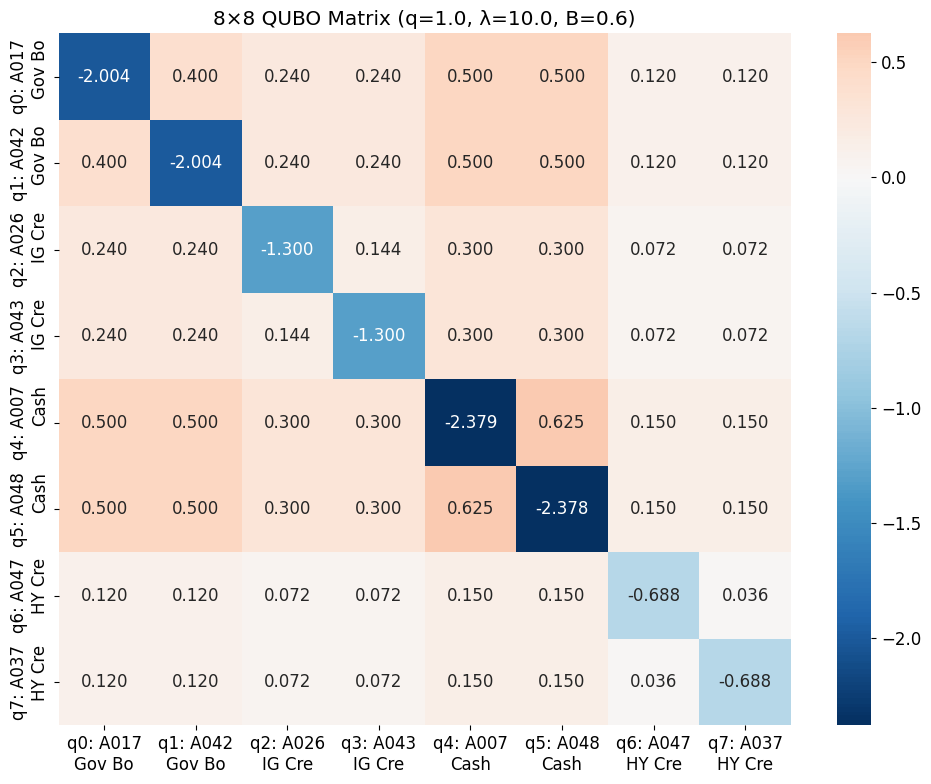

In [13]:
fig, ax = plt.subplots(figsize=(10, 8))
labels = [f'q{i}: {sel8_ids[i]}\n{sectors[i][:6]}' for i in range(n)]
sns.heatmap(Q, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_title(f'8\u00d78 QUBO Matrix (q={q_risk}, \u03bb={lam}, B={B})')
plt.tight_layout()
plt.show()

## 5. Brute-Force All 256 States

In [14]:
all_results = []
for bits in range(2**n):
    x = np.array([(bits >> i) & 1 for i in range(n)], dtype=float)
    w = x * w_max
    obj = float(x @ Q @ x + offset)
    ret = float(mu @ w)
    risk = float(np.sqrt(max(w @ cov8 @ w, 0)))
    
    all_results.append({
        'x': x.astype(int).tolist(),
        'label': ''.join(map(str, x.astype(int).tolist())),
        'objective': round(obj, 6),
        'total_weight': round(w.sum(), 4),
        'return': round(ret, 6),
        'risk': round(risk, 6),
        'n_assets': int(x.sum())
    })

all_results.sort(key=lambda r: r['objective'])

print(f'=== Top 20 Portfolios (out of 256, sorted by objective) ===')
print(f'Budget target B = {B}')
print(f'{"Rank":>4} {"State":>12} {"\u03a3w":>6} {"Return":>9} {"Risk":>9} {"Objective":>10} {"#Assets":>7}')
print('-' * 65)
for i, r in enumerate(all_results[:20]):
    marker = ' \u25c0 BEST' if i == 0 else ''
    print(f"{i+1:>4} {r['label']:>12} {r['total_weight']:>6.3f} "
          f"{r['return']:>9.6f} {r['risk']:>9.6f} {r['objective']:>10.6f} {r['n_assets']:>7}{marker}")

ground = all_results[0]
sel_names = [f'{sel8_ids[i]}({sectors[i][:5]})' for i in range(n) if ground['x'][i]==1]
print(f'\nGround state: x={ground["x"]} \u2192 {sel_names}')
print(f'Total weight: {ground["total_weight"]:.3f} (target: {B})')

# Show invest nothing rank
nothing = [r for r in all_results if r['label'] == '0'*n][0]
print(f'\nInvest nothing: objective = {nothing["objective"]:.4f} (rank {all_results.index(nothing)+1}/256)')

=== Top 20 Portfolios (out of 256, sorted by objective) ===
Budget target B = 0.6
Rank        State     Σw    Return      Risk  Objective #Assets
-----------------------------------------------------------------
   1     00111011  0.610  0.021366  0.019241  -0.019996       5 ◀ BEST
   2     00110111  0.610  0.020676  0.019100  -0.019311       5
   3     00001111  0.620  0.016343  0.014614  -0.012130       4
   4     11010001  0.580  0.016170  0.018370  -0.011833       4
   5     11010010  0.580  0.016092  0.018097  -0.011764       4
   6     11100001  0.580  0.015754  0.017806  -0.011437       4
   7     11100010  0.580  0.015676  0.017483  -0.011370       4
   8     00011100  0.620  0.011929  0.009104  -0.007846       3
   9     00101100  0.620  0.011513  0.008281  -0.007444       3
  10     10011001  0.630  0.016644  0.014397  -0.007437       4
  11     01011001  0.630  0.016603  0.014723  -0.007386       4
  12     10011010  0.630  0.016566  0.014099  -0.007367       4
  13     1000

## 6. Probability Distribution

A quantum computer gives a **probability distribution** over all possible states. The ground state should have the highest probability.

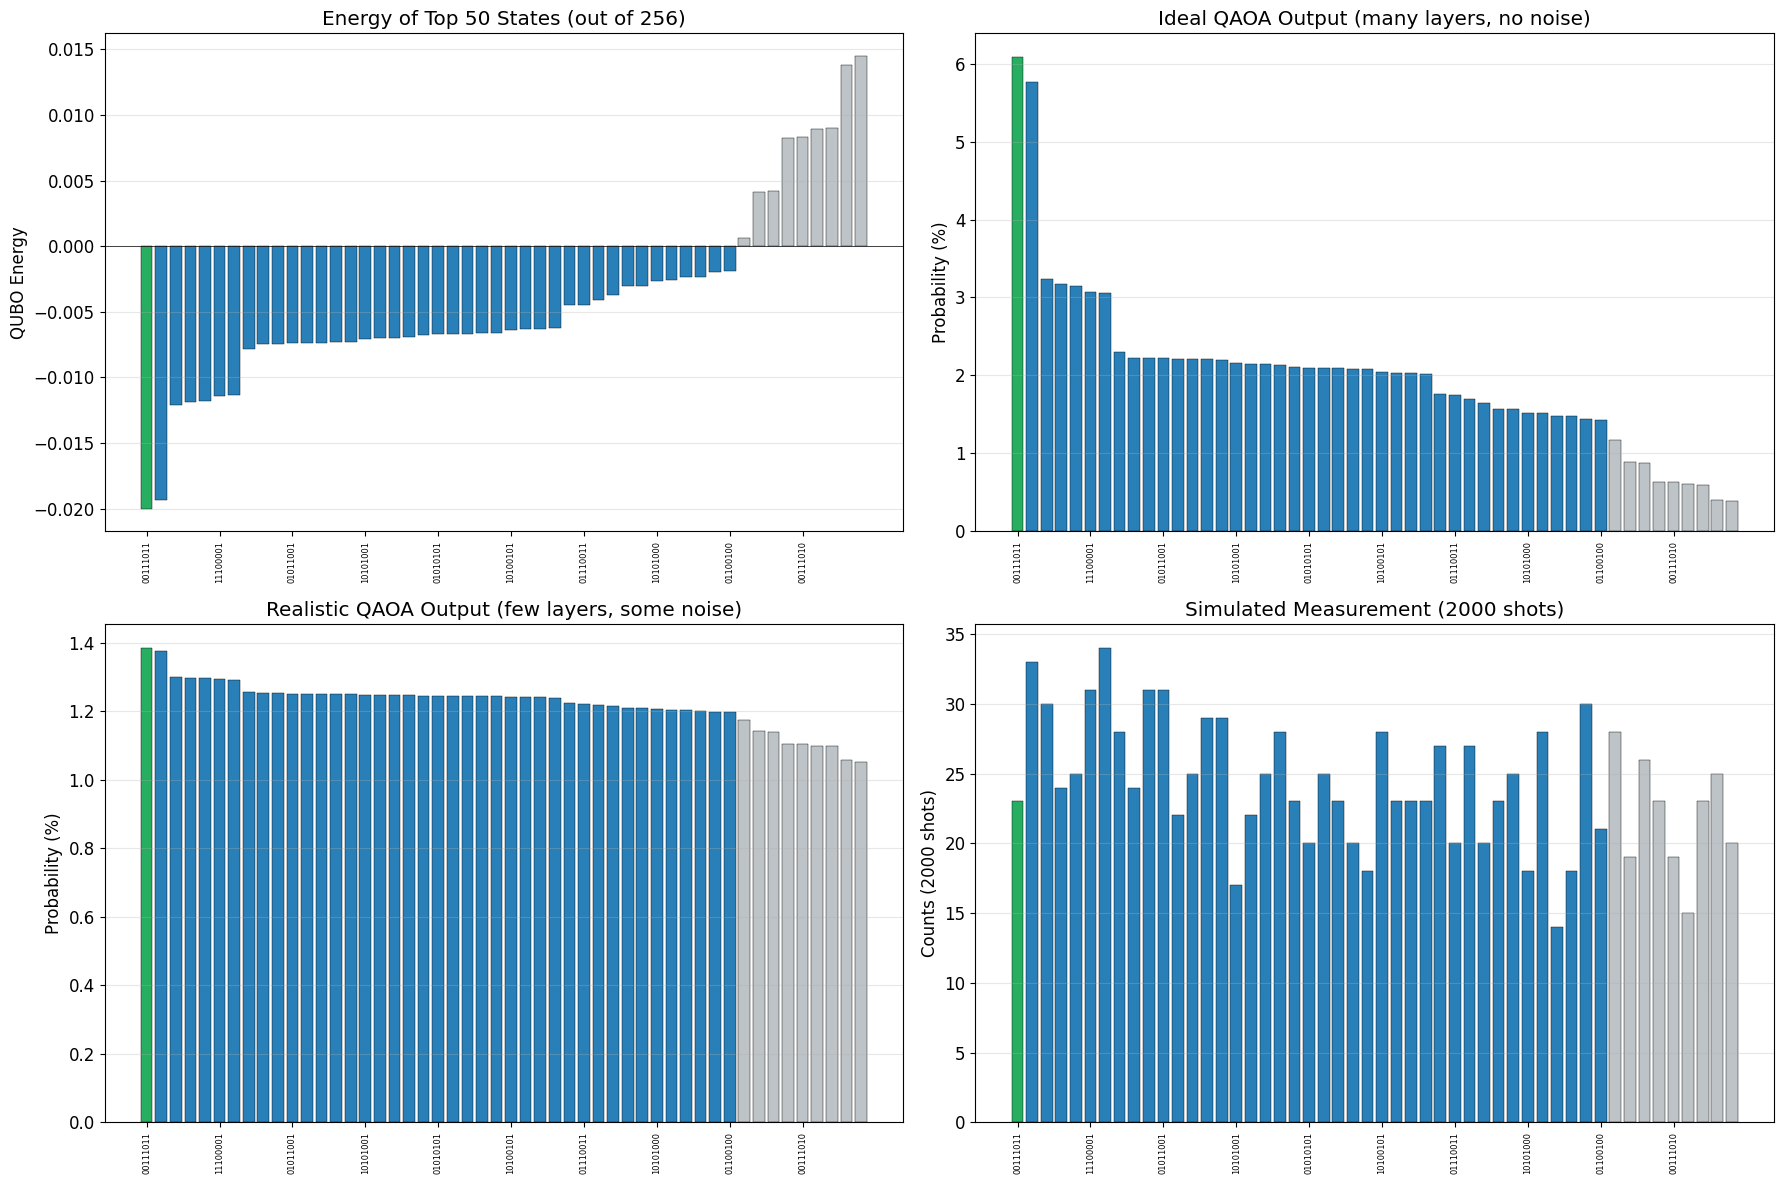

Rank        State     Energy   Ideal%    Real%   Counts
----------------------------------------------------------
   1     00111011    -0.0200    6.08%    1.38%       23
   2     00110111    -0.0193    5.76%    1.38%       33
   3     00001111    -0.0121    3.24%    1.30%       30
   4     11010001    -0.0118    3.17%    1.30%       24
   5     11010010    -0.0118    3.15%    1.30%       25
   6     11100001    -0.0114    3.07%    1.29%       31
   7     11100010    -0.0114    3.05%    1.29%       34
   8     00011100    -0.0078    2.30%    1.26%       28
   9     00101100    -0.0074    2.23%    1.25%       24
  10     10011001    -0.0074    2.23%    1.25%       31
  11     01011001    -0.0074    2.22%    1.25%       31
  12     10011010    -0.0074    2.22%    1.25%       22
  13     10001011    -0.0073    2.21%    1.25%       25
  14     01011010    -0.0073    2.21%    1.25%       29
  15     01001011    -0.0073    2.20%    1.25%       29


In [15]:
energies = np.array([r['objective'] for r in all_results])
state_labels = [r['label'] for r in all_results]

zero_label = '0' * n
bar_colors = []
for i, r in enumerate(all_results):
    if i == 0:
        bar_colors.append('#27ae60')
    elif r['label'] == zero_label:
        bar_colors.append('#e74c3c')
    elif r['objective'] < 0:
        bar_colors.append('#2980b9')
    else:
        bar_colors.append('#bdc3c7')

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

top_n = 50

# Plot 1: Energy landscape
axes[0][0].bar(range(top_n), energies[:top_n], color=bar_colors[:top_n], edgecolor='black', linewidth=0.3)
axes[0][0].set_xticks(range(0, top_n, 5))
axes[0][0].set_xticklabels([state_labels[i] for i in range(0, top_n, 5)], rotation=90, fontsize=6)
axes[0][0].set_ylabel('QUBO Energy')
axes[0][0].set_title(f'Energy of Top 50 States (out of 256)')
axes[0][0].axhline(0, color='black', linewidth=0.5)
axes[0][0].grid(True, alpha=0.3, axis='y')

# Plot 2: Ideal QAOA probability
beta_ideal = 80
boltz_ideal = np.exp(-beta_ideal * (energies - energies.min()))
prob_ideal = boltz_ideal / boltz_ideal.sum()

axes[0][1].bar(range(top_n), prob_ideal[:top_n] * 100, color=bar_colors[:top_n], edgecolor='black', linewidth=0.3)
axes[0][1].set_xticks(range(0, top_n, 5))
axes[0][1].set_xticklabels([state_labels[i] for i in range(0, top_n, 5)], rotation=90, fontsize=6)
axes[0][1].set_ylabel('Probability (%)')
axes[0][1].set_title('Ideal QAOA Output (many layers, no noise)')
axes[0][1].grid(True, alpha=0.3, axis='y')

# Plot 3: Realistic QAOA probability
beta_real = 8
boltz_real = np.exp(-beta_real * (energies - energies.min()))
prob_real = boltz_real / boltz_real.sum()

axes[1][0].bar(range(top_n), prob_real[:top_n] * 100, color=bar_colors[:top_n], edgecolor='black', linewidth=0.3)
axes[1][0].set_xticks(range(0, top_n, 5))
axes[1][0].set_xticklabels([state_labels[i] for i in range(0, top_n, 5)], rotation=90, fontsize=6)
axes[1][0].set_ylabel('Probability (%)')
axes[1][0].set_title('Realistic QAOA Output (few layers, some noise)')
axes[1][0].grid(True, alpha=0.3, axis='y')

# Plot 4: Simulated shots
shots = 2000
samples = np.random.choice(range(256), size=shots, p=prob_real)
counts = np.bincount(samples, minlength=256)

axes[1][1].bar(range(top_n), counts[:top_n], color=bar_colors[:top_n], edgecolor='black', linewidth=0.3)
axes[1][1].set_xticks(range(0, top_n, 5))
axes[1][1].set_xticklabels([state_labels[i] for i in range(0, top_n, 5)], rotation=90, fontsize=6)
axes[1][1].set_ylabel(f'Counts ({shots} shots)')
axes[1][1].set_title(f'Simulated Measurement ({shots} shots)')
axes[1][1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f'{"Rank":>4} {"State":>12} {"Energy":>10} {"Ideal%":>8} {"Real%":>8} {"Counts":>8}')
print('-' * 58)
for i in range(15):
    print(f"{i+1:>4} {state_labels[i]:>12} {energies[i]:>10.4f} "
          f"{prob_ideal[i]*100:>7.2f}% {prob_real[i]*100:>7.2f}% {counts[i]:>8}")

## 7. How Budget Changes the Solution

In [16]:
print('=== Optimal Portfolio vs Budget Target ===')
print(f'{"B":>5} {"Best x":>20} {"#Sel":>4} {"\u03a3w":>6} {"Ret":>9} {"Risk":>9}')
print('-' * 65)

for B_val in np.arange(0.10, 1.30, 0.05):
    Q_tmp, off_tmp = build_qubo(mu, cov8, w_max, q_risk, lam, B_val)
    best_obj = float('inf')
    best_x = None
    for bits in range(256):
        x = np.array([(bits >> i) & 1 for i in range(n)], dtype=float)
        obj = x @ Q_tmp @ x + off_tmp
        if obj < best_obj:
            best_obj = obj
            best_x = x.astype(int).tolist()
    w = np.array(best_x) * w_max
    n_sel = sum(best_x)
    print(f"{B_val:>5.2f} {str(best_x):>20} {n_sel:>4} "
          f"{w.sum():>6.3f} {float(mu@w):>9.6f} {float(np.sqrt(max(w@cov8@w,0))):>9.6f}")

print(f'\nDifferent budgets select different asset combinations.')

=== Optimal Portfolio vs Budget Target ===
    B               Best x #Sel     Σw       Ret      Risk
-----------------------------------------------------------------
 0.10 [0, 0, 0, 0, 0, 0, 1, 1]    2  0.120  0.008837  0.012789
 0.15 [0, 0, 0, 1, 0, 0, 0, 1]    2  0.180  0.008881  0.010562
 0.20 [0, 0, 0, 1, 0, 0, 0, 1]    2  0.180  0.008881  0.010562
 0.25 [0, 0, 0, 1, 0, 0, 1, 1]    3  0.240  0.013261  0.015316
 0.30 [0, 0, 1, 1, 0, 0, 0, 1]    3  0.300  0.012888  0.014574
 0.35 [0, 0, 1, 1, 0, 0, 1, 1]    4  0.360  0.017268  0.018518
 0.40 [1, 0, 0, 1, 0, 0, 0, 1]    3  0.380  0.012546  0.013590
 0.45 [1, 0, 0, 1, 0, 0, 1, 1]    4  0.440  0.016926  0.017700
 0.50 [1, 0, 1, 1, 0, 0, 0, 1]    4  0.500  0.016554  0.017227
 0.55 [1, 0, 1, 1, 0, 0, 1, 1]    5  0.560  0.020933  0.020805
 0.60 [0, 0, 1, 1, 1, 0, 1, 1]    5  0.610  0.021366  0.019241
 0.65 [1, 1, 0, 1, 0, 0, 1, 1]    5  0.640  0.020550  0.021799
 0.70 [1, 1, 1, 1, 0, 0, 0, 1]    5  0.700  0.020177  0.021476
 0.75 [1, 1, 

## 8. QUBO to Ising Conversion

In [21]:
def qubo_to_ising(Q):
    """
    Convert full symmetric QUBO:
        E(x) = x^T Q x + offset
    to Ising:
        E(s) = sum_{i<j} J_ij s_i s_j + sum_i h_i s_i + const
    with x_i = (1 + s_i)/2
    """
    n = Q.shape[0]
    J = np.zeros((n, n), dtype=float)
    h = np.zeros(n, dtype=float)
    ising_offset = 0.0

    for i in range(n):
        # local field
        h[i] = Q[i, i] / 2.0 + sum(Q[i, j] / 2.0 for j in range(n) if j != i)

        # pair couplings
        for j in range(i + 1, n):
            J[i, j] = Q[i, j] / 2.0

    # constant part from Q -> Ising
    ising_offset += sum(Q[i, i] / 2.0 for i in range(n))
    ising_offset += sum(Q[i, j] / 2.0 for i in range(n) for j in range(i + 1, n))

    return J, h, ising_offset


J, h, ising_offset = qubo_to_ising(Q)


print('=== Ising Hamiltonian ===')
print(f'H = Sigma J_ij s_i s_j + Sigma h_i s_i + const')
print(f'where s_i in {{-1, +1}}, related to QUBO by x_i = (1 + s_i)/2')
print(f'\nLocal fields h:')
for i in range(n):
    print(f'  h[{i}] ({sel8_ids[i]:>4}, {sectors[i]:>10}) = {h[i]:>10.6f}')

print(f'\nCouplings J (28 pairs):')
for i in range(n):
    for j in range(i+1, n):
        print(f'  J[{i},{j}] ({sel8_ids[i]}-{sel8_ids[j]}) = {J[i][j]:.6f}')

print(f'\nIsing offset: {ising_offset:.6f}')
print(f'QUBO offset:  {offset:.6f}')
print(f'Total const:  {ising_offset + offset:.6f}')

=== Ising Hamiltonian ===
H = Sigma J_ij s_i s_j + Sigma h_i s_i + const
where s_i in {-1, +1}, related to QUBO by x_i = (1 + s_i)/2

Local fields h:
  h[0] (A017,  Gov Bonds) =   0.058222
  h[1] (A042,  Gov Bonds) =   0.058248
  h[2] (A026,  IG Credit) =   0.034039
  h[3] (A043,  IG Credit) =   0.033841
  h[4] (A007,       Cash) =   0.072964
  h[5] (A048,       Cash) =   0.073309
  h[6] (A047,  HY Credit) =   0.015861
  h[7] (A037,  HY Credit) =   0.015825

Couplings J (28 pairs):
  J[0,1] (A017-A042) = 0.200016
  J[0,2] (A017-A026) = 0.120003
  J[0,3] (A017-A043) = 0.120002
  J[0,4] (A017-A007) = 0.250002
  J[0,5] (A017-A048) = 0.250001
  J[0,6] (A017-A047) = 0.060001
  J[0,7] (A017-A037) = 0.060003
  J[1,2] (A042-A026) = 0.120003
  J[1,3] (A042-A043) = 0.120005
  J[1,4] (A042-A007) = 0.250000
  J[1,5] (A042-A048) = 0.250002
  J[1,6] (A042-A047) = 0.060002
  J[1,7] (A042-A037) = 0.060002
  J[2,3] (A026-A043) = 0.072014
  J[2,4] (A026-A007) = 0.150001
  J[2,5] (A026-A048) = 0.150000
 

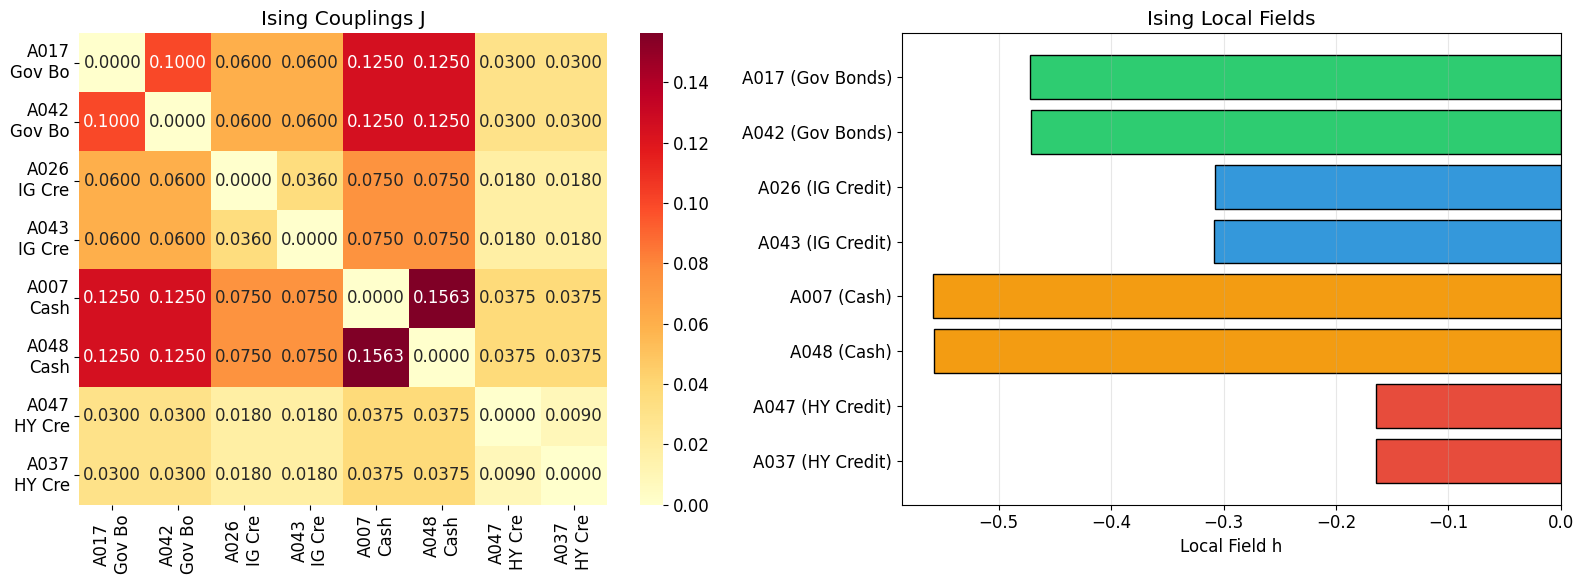

In [18]:
# Visualize Ising structure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

J_sym = J + J.T
labels_short = [f'{sel8_ids[i]}\n{sectors[i][:6]}' for i in range(n)]
sns.heatmap(J_sym, annot=True, fmt='.4f', cmap='YlOrRd',
            xticklabels=labels_short, yticklabels=labels_short, ax=axes[0])
axes[0].set_title('Ising Couplings J')

sector_color_map = {'Gov Bo': '#2ecc71', 'IG Cre': '#3498db', 
                    'Cash': '#f39c12', 'HY Cre': '#e74c3c'}
bar_cols = [sector_color_map.get(sectors[i][:6], '#95a5a6') for i in range(n)]
axes[1].barh(range(n), h, color=bar_cols, edgecolor='black')
axes[1].set_yticks(range(n))
axes[1].set_yticklabels([f'{sel8_ids[i]} ({sectors[i]})' for i in range(n)])
axes[1].set_xlabel('Local Field h')
axes[1].set_title('Ising Local Fields')
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 9. Scenario Validation (1,200 Simulations)

Optimal portfolio: x=[0, 0, 1, 1, 1, 0, 1, 1]
Weights: [0.0, 0.0, 0.12, 0.12, 0.25, 0.0, 0.06, 0.06]
Selected: ['A026(IG Cr)', 'A043(IG Cr)', 'A007(Cash)', 'A047(HY Cr)', 'A037(HY Cr)']

--- 1,200 Scenario Analysis ---
Mean return:  0.000054
Std dev:      0.001208
VaR (95%):    -0.001925
CVaR (95%):   -0.002500


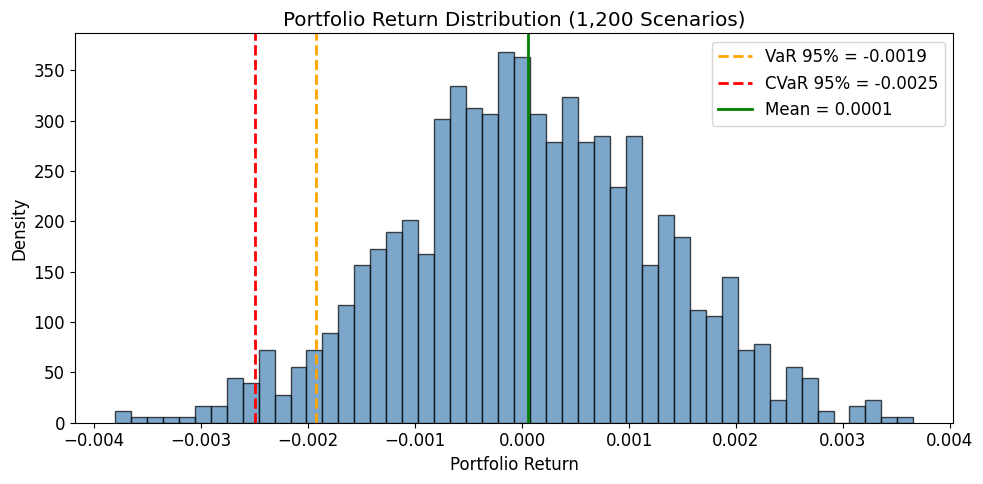

In [19]:
ground = all_results[0]
w_opt = np.array(ground['x']) * w_max

scenario_rets = scenarios[sel8_ids].values @ w_opt
var_95 = np.percentile(scenario_rets, 5)
cvar_95 = scenario_rets[scenario_rets <= var_95].mean()

print(f'Optimal portfolio: x={ground["x"]}')
print(f'Weights: {np.round(w_opt, 4).tolist()}')
sel_names = [f'{sel8_ids[i]}({sectors[i][:5]})' for i in range(n) if ground['x'][i]==1]
print(f'Selected: {sel_names}')
print(f'\n--- 1,200 Scenario Analysis ---')
print(f'Mean return:  {scenario_rets.mean():.6f}')
print(f'Std dev:      {scenario_rets.std():.6f}')
print(f'VaR (95%):    {var_95:.6f}')
print(f'CVaR (95%):   {cvar_95:.6f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(scenario_rets, bins=50, color='steelblue', edgecolor='black', alpha=0.7, density=True)
ax.axvline(var_95, color='orange', ls='--', lw=2, label=f'VaR 95% = {var_95:.4f}')
ax.axvline(cvar_95, color='red', ls='--', lw=2, label=f'CVaR 95% = {cvar_95:.4f}')
ax.axvline(scenario_rets.mean(), color='green', lw=2, label=f'Mean = {scenario_rets.mean():.4f}')
ax.set_xlabel('Portfolio Return')
ax.set_ylabel('Density')
ax.set_title('Portfolio Return Distribution (1,200 Scenarios)')
ax.legend()
plt.tight_layout()
plt.show()

## 10. Save Everything for Step 2 (Bloqade QAOA)

In [20]:
handoff = {
    'encoding': '8 assets x 1 qubit each (2 per Hartford sector)',
    'assets': sel8_ids,
    'sectors': sectors,
    'mu': mu.tolist(),
    'w_max': w_max.tolist(),
    'cov_matrix': cov8.tolist(),
    'Q_matrix': Q.tolist(),
    'qubo_offset': offset,
    'J_matrix': J.tolist(),
    'h_fields': h.tolist(),
    'ising_offset': ising_offset,
    'params': {'q': q_risk, 'lambda': lam, 'B': B},
    'ground_truth': all_results[0],
    'top_20': all_results[:20]
}

with open('step2_handoff_8qubit_hartford.json', 'w') as f:
    json.dump(handoff, f, indent=2)

print('=== Step 1 Complete (8 Qubits, Hartford Sectors) ===')
print(f'\nSaved: step2_handoff_8qubit_hartford.json')
print(f'\nGround truth: x = {all_results[0]["x"]}')
print(f'Energy: {all_results[0]["objective"]}')
print(f'Assets: {[sel8_ids[i] for i in range(n) if all_results[0]["x"][i]==1]}')
print(f'\nReady for Step 2:')
print(f'  1. Build QAOA circuit on Bloqade (8 qubits)')
print(f'  2. Get quantum probability distribution')
print(f'  3. Compare with brute-force ground truth')
print(f'  4. Add noise analysis')

=== Step 1 Complete (8 Qubits, Hartford Sectors) ===

Saved: step2_handoff_8qubit_hartford.json

Ground truth: x = [0, 0, 1, 1, 1, 0, 1, 1]
Energy: -0.019996
Assets: ['A026', 'A043', 'A007', 'A047', 'A037']

Ready for Step 2:
  1. Build QAOA circuit on Bloqade (8 qubits)
  2. Get quantum probability distribution
  3. Compare with brute-force ground truth
  4. Add noise analysis
